# What Makes Countries Happy?
### A Visual Exploration of Global Well-Being (2015–2022)

This project explores global happiness trends using data from the World Happiness Report. While economic wealth is often assumed to drive happiness, this analysis investigates whether social and structural factors such as support systems, health, and freedom play a larger role.

The goal is to identify the key factors associated with national happiness and understand how well-being has changed across countries over time.

## Research Questions

This analysis is guided by the following questions:

- What factors best explain differences in national happiness scores?
- Does GDP per capita significantly increase happiness?
- Are social support and freedom stronger predictors than income?
- How has global happiness changed over time?

In [12]:
import pandas as pd
import numpy as np

files = {
    2015: "../data/raw/2015.csv",
    2016: "../data/raw/2016.csv",
    2017: "../data/raw/2017.csv",
    2018: "../data/raw/2018.csv",
    2019: "../data/raw/2019.csv",
    2020: "../data/raw/2020.csv",
    2021: "../data/raw/2021.csv",
    2022: "../data/raw/2022.csv"
}

column_map = {
    "Country": "Country",
    "Country or region": "Country",
    "Country name": "Country",

    "Happiness Score": "Happiness Score",
    "Happiness.Score": "Happiness Score",
    "Score": "Happiness Score",
    "Ladder score": "Happiness Score",
    "Happiness score": "Happiness Score",

    "Economy (GDP per Capita)": "GDP per capita",
    "Economy..GDP.per.Capita.": "GDP per capita",
    "GDP per capita": "GDP per capita",
    "Explained by: GDP per capita": "GDP per capita",

    "Family": "Social Support",
    "Social support": "Social Support",
    "Explained by: Social support": "Social Support",

    "Health (Life Expectancy)": "Healthy Life Expectancy",
    "Health..Life.Expectancy.": "Healthy Life Expectancy",
    "Healthy life expectancy": "Healthy Life Expectancy",
    "Explained by: Healthy life expectancy": "Healthy Life Expectancy",

    "Freedom": "Freedom",
    "Freedom to make life choices": "Freedom",
    "Explained by: Freedom to make life choices": "Freedom",

    "Generosity": "Generosity",
    "Explained by: Generosity": "Generosity",

    "Trust (Government Corruption)": "Corruption",
    "Trust..Government.Corruption.": "Corruption",
    "Perceptions of corruption": "Corruption",
    "Explained by: Perceptions of corruption": "Corruption",
}

keep_cols = [
    "Year",
    "Country",
    "Happiness Score",
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

all_dfs = []

for year, path in files.items():
    temp = pd.read_csv(path)
    temp.columns = temp.columns.str.strip()

    # fix comma decimals only for object columns
    for c in temp.columns:
        if temp[c].dtype == object:
            temp[c] = temp[c].astype(str).str.replace(",", ".", regex=False)

    # rename
    temp = temp.rename(columns=column_map)

    # remove duplicated column names after renaming
    temp = temp.loc[:, ~temp.columns.duplicated()]

    # add year
    temp["Year"] = year

    # add any missing columns
    for c in keep_cols:
        if c not in temp.columns:
            temp[c] = np.nan

    # keep only final columns
    temp = temp[keep_cols].copy()

    # convert numeric columns one by one
    numeric_cols = [
        "Year",
        "Happiness Score",
        "GDP per capita",
        "Social Support",
        "Healthy Life Expectancy",
        "Freedom",
        "Generosity",
        "Corruption"
    ]

    for c in numeric_cols:
        temp[c] = pd.to_numeric(temp[c], errors="coerce")

    all_dfs.append(temp)

df = pd.concat(all_dfs, ignore_index=True)

# optional cleanup
df = df.drop_duplicates()
df = df.dropna(subset=["Country", "Happiness Score"])

print(df.shape)
print(sorted(df["Year"].unique()))
print(df.head())

df.to_csv("../data/processed/final_happiness_dataset.csv", index=False)

(1230, 9)
[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
   Year      Country  Happiness Score  GDP per capita  Social Support  \
0  2015  Switzerland            7.587         1.39651         1.34951   
1  2015      Iceland            7.561         1.30232         1.40223   
2  2015      Denmark            7.527         1.32548         1.36058   
3  2015       Norway            7.522         1.45900         1.33095   
4  2015       Canada            7.427         1.32629         1.32261   

   Healthy Life Expectancy  Freedom  Generosity  Corruption  
0                  0.94143  0.66557     0.29678     0.41978  
1                  0.94784  0.62877     0.43630     0.14145  
2                  0.87464  0.64938     0.34139     0.48357  
3                  0.88521  0.66973     0.34699     0.36503  
4                  0.90563  0.63297     0.45811     0.32957  


## Dataset Description

The dataset used is the World Happiness Report (2015–2022), which includes approximately 150 countries per year.

Each row represents a country in a specific year and includes measures of:

- Happiness Score
- GDP per capita
- Social Support
- Healthy Life Expectancy
- Freedom to make life choices
- Generosity
- Perceptions of corruption

Due to inconsistencies across years, the datasets were merged and standardized into a single cleaned dataset before analysis.

In [13]:
df.tail()

,Year,Country,Happiness Score,GDP per capita,Social Support,Healthy Life Expectancy,Freedom,Generosity,Corruption
1225,2022,Botswana*,3.471,1.503,0.815,0.280,0.571,0.012,0.102
1226,2022,Rwanda*,3.268,0.785,0.133,0.462,0.621,0.187,0.544
1227,2022,Zimbabwe,2.995,0.947,0.690,0.270,0.329,0.106,0.105
1228,2022,Lebanon,2.955,1.392,0.498,0.631,0.103,0.082,0.034
1229,2022,Afghanistan,2.404,0.758,0.000,0.289,0.000,0.089,0.005


In [14]:
df.head()

,Year,Country,Happiness Score,GDP per capita,Social Support,Healthy Life Expectancy,Freedom,Generosity,Corruption
0,2015,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.29678,0.41978
1,2015,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.43630,0.14145
2,2015,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.34139,0.48357
3,2015,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.34699,0.36503
4,2015,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.45811,0.32957


In [15]:
print(year, temp.columns[temp.columns.duplicated()].tolist())

2022 []


In [16]:
print(df[df["Year"] == 2022].head())
print(df[df["Year"] == 2022].isnull().sum())

      Year      Country  Happiness Score  GDP per capita  Social Support  \
1084  2022      Finland            7.821           1.892           1.258   
1085  2022      Denmark            7.636           1.953           1.243   
1086  2022      Iceland            7.557           1.936           1.320   
1087  2022  Switzerland            7.512           2.026           1.226   
1088  2022  Netherlands            7.415           1.945           1.206   

      Healthy Life Expectancy  Freedom  Generosity  Corruption  
1084                    0.775    0.736       0.109       0.534  
1085                    0.777    0.719       0.188       0.532  
1086                    0.803    0.718       0.270       0.191  
1087                    0.822    0.677       0.147       0.461  
1088                    0.787    0.651       0.271       0.419  
Year                       0
Country                    0
Happiness Score            0
GDP per capita             0
Social Support             0
Healthy 

## Data Cleaning and Preparation

The data required preprocessing due to structural differences across years. Key steps included:

- Merging datasets from 2015–2022
- Standardizing column names across files
- Converting numeric values (especially from 2022 formatting)
- Handling missing values
- Ensuring consistent data types for analysis

The final dataset contains all countries across all years in a unified format.

In [39]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_happiness_dataset.csv")

In [40]:
print(df.shape)
print(sorted(df["Year"].unique()))
print(df.isnull().sum())

(1230, 9)
[2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Year                         0
Country                      0
Happiness Score              0
GDP per capita             302
Social Support               0
Healthy Life Expectancy      0
Freedom                      0
Generosity                   0
Corruption                   1
dtype: int64


## Exploratory Data Analysis

Before building visualizations, summary statistics and distributions were examined to understand the data.

This included:
- Descriptive statistics
- Identifying top and bottom countries by happiness
- Checking missing values
- Understanding variable ranges

These steps helped guide the selection of meaningful visualizations.

In [41]:
df.describe()

,Year,Happiness Score,GDP per capita,Social Support,Healthy Life Expectancy,Freedom,Generosity,Corruption
count,1230.000000,1230.000000,928.000000,1230.000000,1230.000000,1230.000000,1230.000000,1229.000000
mean,2018.447154,5.430092,0.993830,0.992431,16.348441,0.516090,0.152812,0.277559
std,2.282716,1.115361,0.447263,0.308718,27.814628,0.213859,0.159886,0.289185
min,2015.000000,2.404000,0.000000,0.000000,0.000000,0.000000,-0.300907,0.000000
25%,2016.000000,4.584500,0.682000,0.802000,0.539000,0.375128,0.074000,0.068106
50%,2018.000000,5.410500,1.028435,0.949559,0.731860,0.508000,0.155699,0.135000
75%,2020.000000,6.226225,1.316024,1.225750,1.044250,0.651325,0.244255,0.411000
max,2022.000000,7.842000,2.209000,1.644000,76.953000,0.974998,0.838075,0.939000


In [42]:
country_avg = (
    df.groupby("Country", as_index=False)["Happiness Score"]
    .mean()
    .sort_values("Happiness Score", ascending=False)
)

print(country_avg.head(10))
print(country_avg.tail(10))

         Country  Happiness Score
54       Finland         7.645087
45       Denmark         7.578950
168  Switzerland         7.524987
72       Iceland         7.521313
132       Norway         7.493750
122  Netherlands         7.418863
101  Luxembourg*         7.404000
167       Sweden         7.337062
123  New Zealand         7.292700
28        Canada         7.264137
                      Country  Happiness Score
173                  Tanzania         3.516400
94                   Lesotho*         3.512000
21                  Botswana*         3.471000
147                    Rwanda         3.417186
169                     Syria         3.292200
25                    Burundi         3.277900
161               South Sudan         3.269320
148                   Rwanda*         3.268000
29   Central African Republic         3.202580
0                 Afghanistan         3.132237


In [43]:
#chloropleth
fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Happiness Score",
    animation_frame="Year",
    hover_name="Country",
    hover_data=[
        "GDP per capita",
        "Social Support",
        "Healthy Life Expectancy",
        "Freedom",
        "Generosity",
        "Corruption"
    ],
    color_continuous_scale="Viridis",
    title="Global Happiness Scores Over Time"
)

fig.update_layout(title_x=0.5)
fig.show()

## Global Happiness Distribution (Choropleth Map)

This interactive map shows how happiness scores vary across countries and over time.

### Key Insight:
The choropleth map reveals strong geographic disparities in global happiness. Countries in Northern and Western Europe consistently report the highest happiness scores, while many countries in Africa and parts of South Asia show lower scores.

Across the years, these patterns remain relatively stable, indicating that global happiness is influenced by long-term structural factors rather than short-term fluctuations.

This visualization helps answer:
- How does happiness vary geographically?
- How has it changed over time?

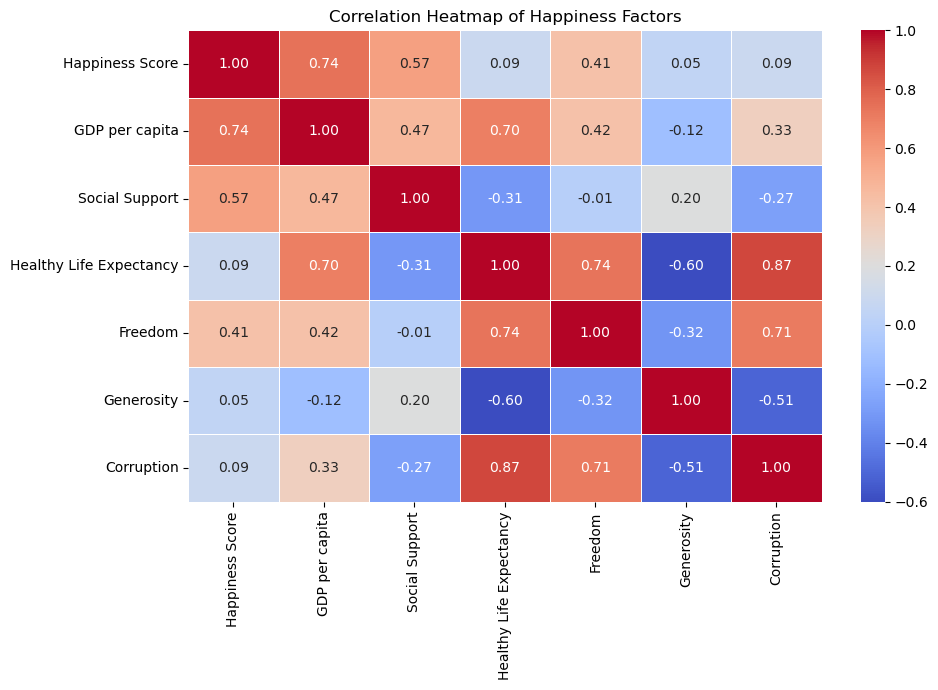

In [44]:
#correlation heatmap
corr_cols = [
    "Happiness Score",
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Happiness Factors")
plt.tight_layout()
plt.show()

## Correlation Between Happiness and Key Factors

This heatmap shows the strength of relationships between happiness and other variables.

### Key Insight:
GDP per capita has the strongest positive correlation with happiness (0.74), followed by social support (0.57) and freedom (0.41).

This indicates that economic prosperity plays the most significant role in explaining differences in happiness across countries, while social and personal freedoms also contribute meaningfully.

Other factors such as corruption, life expectancy, and generosity show relatively weak relationships with happiness in this dataset.

In [58]:
#radar chart
top5 = country_avg.head(5)["Country"].tolist()
bottom5 = country_avg.tail(5)["Country"].tolist()

radar_features = [
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

top_profile = df[df["Country"].isin(top5)][radar_features].mean()
bottom_profile = df[df["Country"].isin(bottom5)][radar_features].mean()

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=top_profile.values,
    theta=radar_features,
    fill="toself",
    name="Top 5 Happiest Countries"
))

fig.add_trace(go.Scatterpolar(
    r=bottom_profile.values,
    theta=radar_features,
    fill="toself",
    name="Bottom 5 Happiest Countries"
))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True)),
    title="Top 5 vs Bottom 5 Happiest Countries",
    title_x=0.5
)

fig.show()

In [60]:
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# average values by country
country_avg = (
    df.groupby("Country", as_index=False)[
        ["Happiness Score", "GDP per capita", "Social Support",
         "Healthy Life Expectancy", "Freedom"]
    ]
    .mean()
    .sort_values("Happiness Score", ascending=False)
)

top5 = country_avg.head(5)["Country"].tolist()
bottom5 = country_avg.tail(5)["Country"].tolist()

simple_features = [
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom"
]

# normalize these 4 features across all countries
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(country_avg[simple_features])

scaled_df = country_avg.copy()
scaled_df[simple_features] = scaled_values

top_profile = scaled_df[scaled_df["Country"].isin(top5)][simple_features].mean()
bottom_profile = scaled_df[scaled_df["Country"].isin(bottom5)][simple_features].mean()

fig = go.Figure()

fig.add_trace(go.Scatterpolar(
    r=top_profile.values,
    theta=simple_features,
    fill="toself",
    name="Top 5 Happiest Countries"
))

fig.add_trace(go.Scatterpolar(
    r=bottom_profile.values,
    theta=simple_features,
    fill="toself",
    name="Bottom 5 Happiest Countries"
))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    title="Normalized Radar Chart: Top 5 vs Bottom 5 Happiest Countries",
    title_x=0.5
)

fig.show()

## Normalized Radar Chart: Top vs Bottom Countries

This radar chart compares the top 5 happiest countries with the bottom 5 happiest countries using normalized values for GDP per capita, social support, healthy life expectancy, and freedom.

### Key Insight:
After scaling all variables to the same range, the happiest countries still extend farther from the center across most factors. This shows that the top-ranked countries generally perform better in economic conditions, social support, health, and freedom than the bottom-ranked countries.

In [61]:
# average values by country
country_avg = (
    df.groupby("Country", as_index=False)[
        ["Happiness Score", "GDP per capita", "Social Support",
         "Healthy Life Expectancy", "Freedom"]
    ]
    .mean()
    .sort_values("Happiness Score", ascending=False)
)

top5 = country_avg.head(5)["Country"].tolist()
bottom5 = country_avg.tail(5)["Country"].tolist()

features = [
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom"
]

# average profiles for the two groups
top_profile = df[df["Country"].isin(top5)][features].mean()
bottom_profile = df[df["Country"].isin(bottom5)][features].mean()

bar_df = pd.DataFrame({
    "Factor": features * 2,
    "Average Value": list(top_profile.values) + list(bottom_profile.values),
    "Group": ["Top 5 Happiest Countries"] * len(features) + ["Bottom 5 Happiest Countries"] * len(features)
})

fig = px.bar(
    bar_df,
    x="Factor",
    y="Average Value",
    color="Group",
    barmode="group",
    title="Top 5 vs Bottom 5 Happiest Countries Across Key Factors"
)

fig.update_layout(title_x=0.5)
fig.show()

## Grouped Bar Chart: Top vs Bottom Countries

This bar chart compares the top 5 happiest countries with the bottom 5 happiest countries across GDP per capita, social support, healthy life expectancy, and freedom.

### Key Insight:
The top 5 happiest countries have higher average values across all four factors. The clearest differences appear in GDP per capita, social support, and freedom, showing that happier countries tend to have stronger economic and social conditions overall.

In [62]:
country_avg = (
    df.groupby("Country", as_index=False)[
        ["Happiness Score", "GDP per capita", "Social Support",
         "Healthy Life Expectancy", "Freedom"]
    ]
    .mean()
    .sort_values("Happiness Score", ascending=False)
)

top5 = country_avg.head(5)["Country"].tolist()
bottom5 = country_avg.tail(5)["Country"].tolist()

features = [
    "GDP per capita",
    "Social Support",
    "Healthy Life Expectancy",
    "Freedom"
]

scaler = MinMaxScaler()
scaled = country_avg.copy()
scaled[features] = scaler.fit_transform(country_avg[features])

top_profile = scaled[scaled["Country"].isin(top5)][features].mean()
bottom_profile = scaled[scaled["Country"].isin(bottom5)][features].mean()

bar_df = pd.DataFrame({
    "Factor": features * 2,
    "Average Value": list(top_profile.values) + list(bottom_profile.values),
    "Group": ["Top 5 Happiest Countries"] * len(features) + ["Bottom 5 Happiest Countries"] * len(features)
})

fig = px.bar(
    bar_df,
    x="Factor",
    y="Average Value",
    color="Group",
    barmode="group",
    title="Normalized Comparison: Top 5 vs Bottom 5 Happiest Countries"
)

fig.update_layout(title_x=0.5, yaxis_title="Normalized Value (0 to 1)")
fig.show()

## Normalized Comparison: Top vs Bottom Countries

This normalized bar chart compares the top 5 happiest countries with the bottom 5 happiest countries across GDP per capita, social support, healthy life expectancy, and freedom.

### Key Insight:
After scaling each variable to the same range, the top 5 happiest countries remain higher across all four factors. The largest differences appear in social support, freedom, and GDP per capita, suggesting that happier countries tend to have stronger economic conditions and social environments overall.

In [46]:
# GDP vs happiness scatter
fig = px.scatter(
    df,
    x="GDP per capita",
    y="Happiness Score",
    color="Year",
    hover_name="Country",
    trendline="ols",
    title="GDP per Capita vs Happiness Score"
)

fig.update_layout(title_x=0.5)
fig.show()

## GDP vs Happiness

This scatter plot examines the relationship between GDP per capita and happiness.

### Key Insight:
There is a strong positive relationship between GDP per capita and happiness, indicating that wealthier countries tend to report higher happiness scores.

However, the variation in points suggests that GDP alone does not fully explain happiness, highlighting the importance of other social and institutional factors.

In [47]:
#avg happiness over time 
year_avg = df.groupby("Year", as_index=False)["Happiness Score"].mean()

fig = px.line(
    year_avg,
    x="Year",
    y="Happiness Score",
    markers=True,
    title="Average Global Happiness Score by Year"
)

fig.update_layout(title_x=0.5)
fig.show()

## Global Happiness Trends Over Time

This line chart shows the average happiness score across all countries by year.

### Key Insight:
Global average happiness shows a gradual upward trend from 2015 to 2022, with a small dip around 2017 followed by steady growth.

This suggests that, despite short-term fluctuations, overall global well-being has improved over time, potentially reflecting gradual economic and social development across countries.

In [48]:
# countries with biggest improvement and decline
country_year = df.sort_values(["Country", "Year"]).copy()

first_scores = country_year.groupby("Country", as_index=False).first()[["Country", "Happiness Score"]]
first_scores = first_scores.rename(columns={"Happiness Score": "first_score"})

last_scores = country_year.groupby("Country", as_index=False).last()[["Country", "Happiness Score"]]
last_scores = last_scores.rename(columns={"Happiness Score": "last_score"})

change_df = first_scores.merge(last_scores, on="Country")
change_df["score_change"] = change_df["last_score"] - change_df["first_score"]

top_improved = change_df.sort_values("score_change", ascending=False).head(10)
top_declined = change_df.sort_values("score_change", ascending=True).head(10)

## Changes in Happiness Over Time

These charts highlight the countries with the greatest improvements and declines in happiness.

### Key Insight:
Happiness is dynamic, with some countries experiencing significant improvements while others decline. This reinforces the importance of examining trends rather than relying only on rankings.

In [49]:
#improvement chart
fig = px.bar(
    top_improved,
    x="score_change",
    y="Country",
    orientation="h",
    title="Top 10 Countries with Greatest Improvement in Happiness",
    labels={"score_change": "Change in Happiness Score"}
)

fig.update_layout(title_x=0.5, yaxis=dict(categoryorder="total ascending"))
fig.show()

Countries with the greatest improvements in happiness are often developing nations, suggesting that even moderate gains in economic or social conditions can lead to noticeable increases in well-being.

This highlights the potential for growth and improvement in happiness as countries develop.

In [50]:
#decline chart
fig = px.bar(
    top_declined,
    x="score_change",
    y="Country",
    orientation="h",
    title="Top 10 Countries with Greatest Decline in Happiness",
    labels={"score_change": "Change in Happiness Score"}
)

fig.update_layout(title_x=0.5, yaxis=dict(categoryorder="total descending"))
fig.show()

Countries experiencing the largest declines in happiness are often those facing economic instability, political conflict, or social disruption.

This suggests that national crises and instability have a significant negative impact on overall well-being.

In [51]:
happiness_corr = corr["Happiness Score"].sort_values(ascending=False)
print(happiness_corr)

Happiness Score            1.000000
GDP per capita             0.740215
Social Support             0.574718
Freedom                    0.414378
Corruption                 0.088389
Healthy Life Expectancy    0.087447
Generosity                 0.048345
Name: Happiness Score, dtype: float64


## Key Findings

- Happiness is influenced by multiple factors, not just income
- Social support and health are strong contributors to well-being
- GDP has a positive relationship but does not fully explain happiness
- Happiness changes over time, indicating it is not fixed
- Countries with strong social and structural systems tend to rank higher

## Limitations

- Happiness scores are self-reported and subjective
- Missing values exist for some countries and years
- Not all countries appear in every year
- Correlation does not imply causation

These limitations should be considered when interpreting results.

## Conclusion

The analysis shows that happiness is strongly associated with economic prosperity, but also influenced by social support and personal freedoms.

While global happiness has improved over time, significant disparities remain across regions, highlighting the importance of long-term economic and social development in improving well-being worldwide.

In [52]:
#The results suggest that happiness is influenced by multiple socioeconomic and structural factors rather than income alone. GDP per capita shows a positive relationship with happiness, but social support and healthy life expectancy appear to be especially strong contributors. The choropleth map reveals clear geographic differences in happiness across countries and years, while the radar chart shows that the happiest countries tend to perform better across several dimensions at once. The time trend and country change analysis also show that happiness is dynamic, with some countries improving and others declining over time.

In [53]:
plt.savefig("../outputs/heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

fig.write_html("../outputs/choropleth_animation.html")

In [56]:
fig.write_html("../outputs/choropleth_animation.html")